
**Usage Notes:**

1. Download `gotham_drv.fits` (~439 MB) from the [GBT Legacy Archive calibrated data directory](https://www.gb.nrao.edu/GbtLegacyArchive/GOTHAM/calibrated/).

2. Install dependencies: `pip install astropy matplotlib numpy`

3. The code produces:
   - Full broadband spectrum plot
   - Zoomed regions (customize `freq_range` and labels for specific molecules like cyanopolyynes, aromatics)
   - Smoothed overview

4. Extend it with `spectral-cube`, `radio-beam`, or the official [GOTHAM Spectral Pipeline](https://github.com/cixue/gotham-spectral-pipeline) for advanced reduction/MCMC fitting.

5. For molecule-specific overlays, reference papers on Zenodo/Harvard Dataverse or the pipeline repository.

This provides a solid starting point for visualizing and analyzing the rich GOTHAM dataset!

Loaded GOTHAM spectrum: 19184386 channels (3944.64 MHz – 36410.59 MHz)


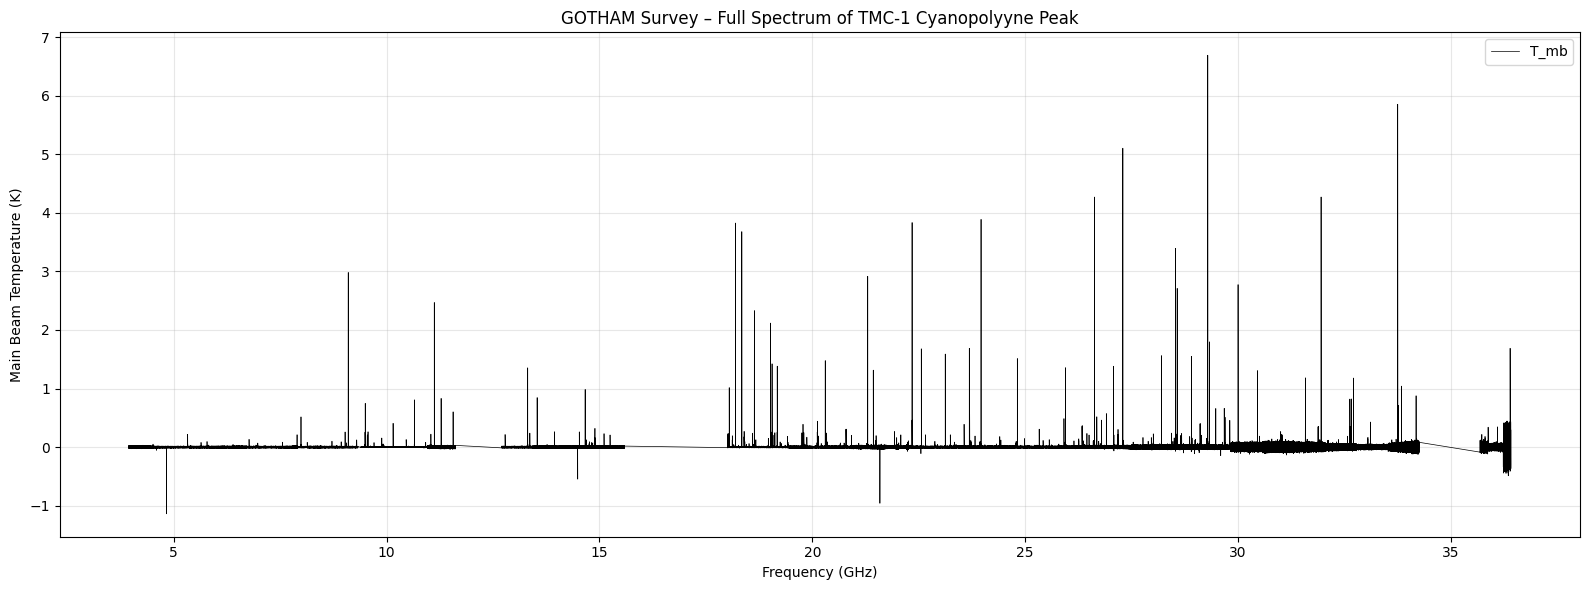

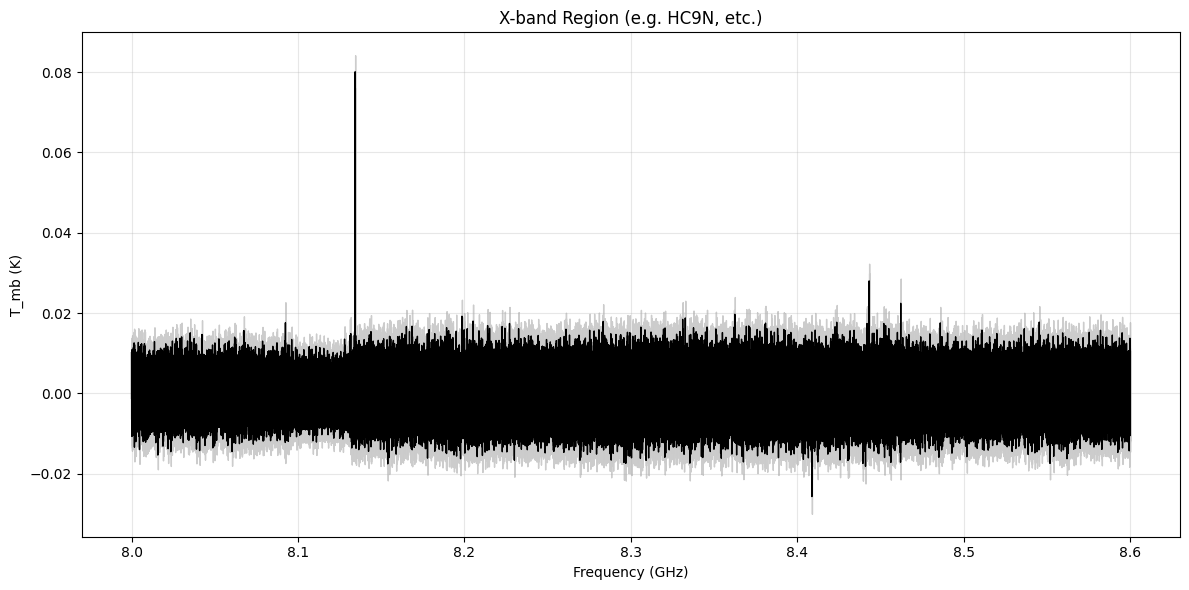

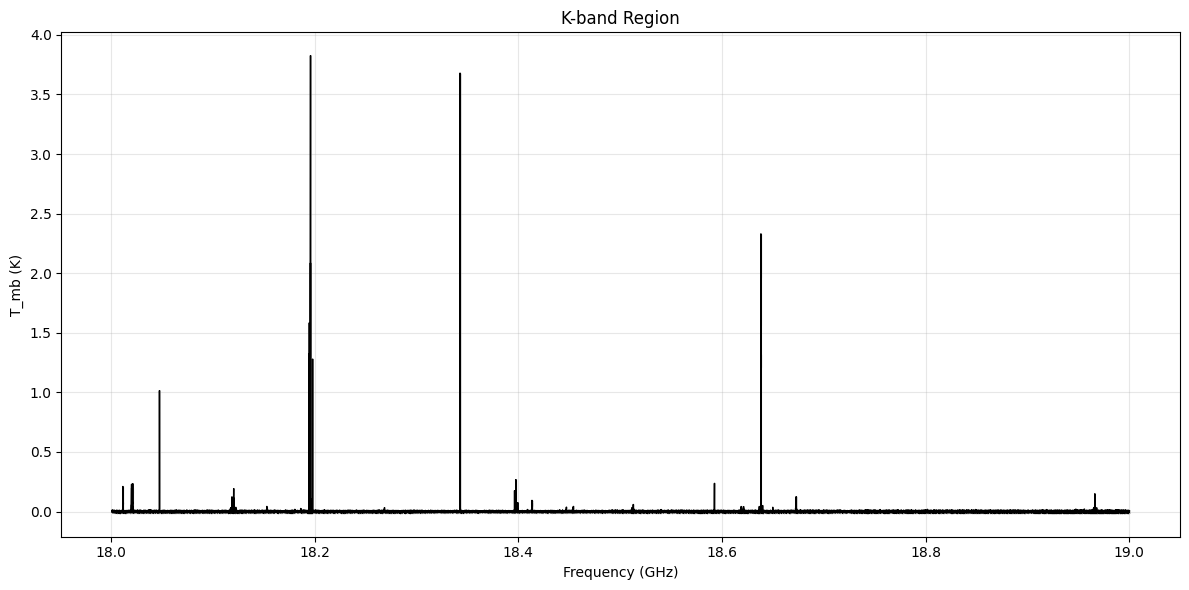

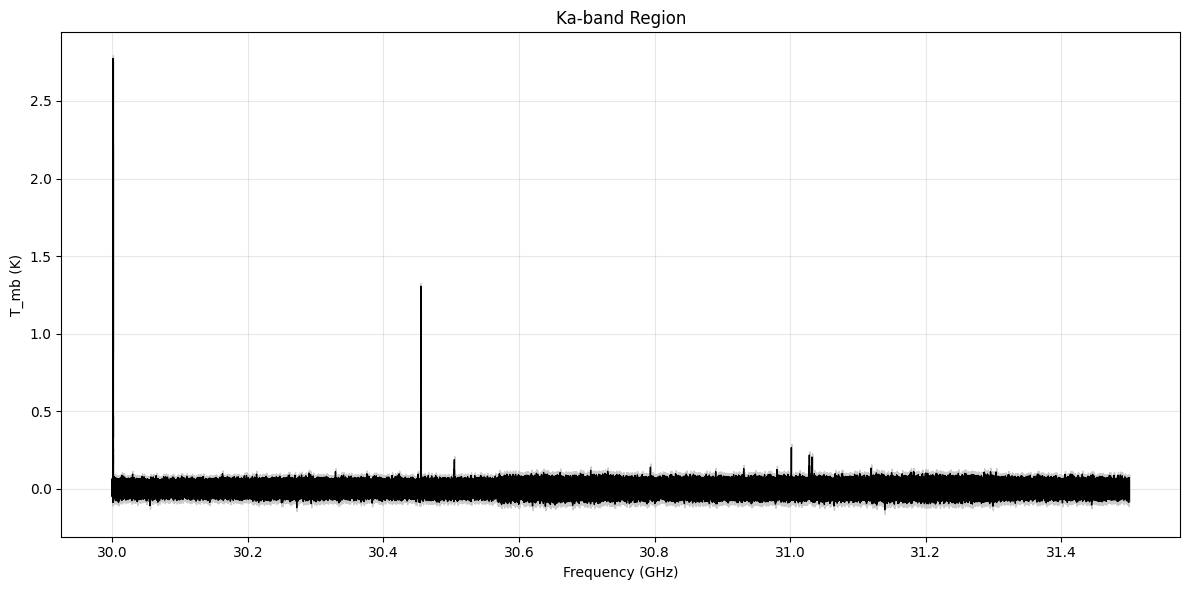

/var/folders/c2/y73585dd0g1bnbknv863zg5r0000gn/T/ipykernel_9147/4107144431.py:145: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/var/folders/c2/y73585dd0g1bnbknv863zg5r0000gn/T/ipykernel_9147/4107144431.py:147: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')


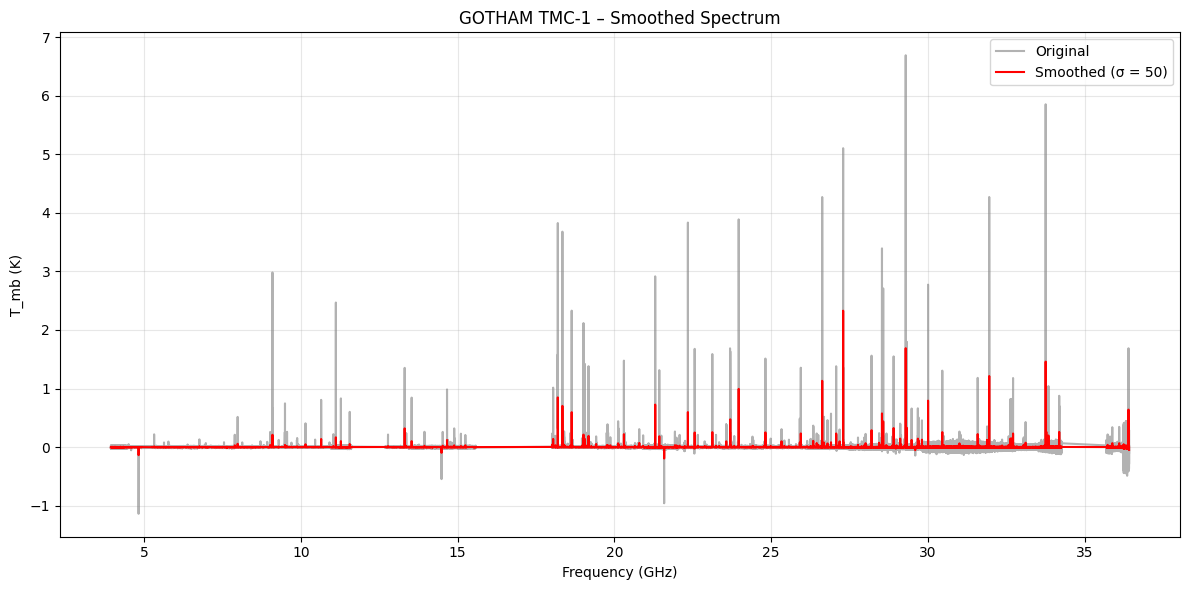

✅ All plots generated successfully!


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy import units as u
from astropy.convolution import convolve, Gaussian1DKernel
import os

# ================================================
# GOTHAM Survey Spectral Analysis Plotting Code
# ================================================

def downsample_for_plot(x, y, max_points=20000):
    """Downsample by binning into max_points bins using min/max envelope."""
    if len(x) <= max_points:
        return x, y

    bins = np.linspace(0, len(x), max_points+1, dtype=int)
    x_ds = []
    y_ds = []

    for i in range(len(bins)-1):
        lo, hi = bins[i], bins[i+1]
        segment = y[lo:hi]
        x_segment = x[lo:hi]

        if len(segment) == 0:
            continue

        # preserve structure: min and max
        idx_min = np.argmin(segment)
        idx_max = np.argmax(segment)

        x_ds.extend([x_segment[idx_min], x_segment[idx_max]])
        y_ds.extend([segment[idx_min], segment[idx_max]])

    return np.array(x_ds), np.array(y_ds)


def load_gotham_data(fits_path='gotham_drv.fits'):
    """Load the GOTHAM calibrated spectrum FITS file."""
    if not os.path.exists(fits_path):
        print(f"File {fits_path} not found.")
        print("Download from: https://www.gb.nrao.edu/GbtLegacyArchive/GOTHAM/calibrated/")
        return None, None, None
    
    with fits.open(fits_path) as hdul:
        data = hdul[1].data

        # Required columns
        freq = data['frequency'] * u.MHz
        tmb  = data['Tmb'] * u.K

        # Optional column: Tmb_error
        if 'Tmb_error' in data.columns.names:
            tmb_error = data['Tmb_error'] * u.K
        else:
            print("⚠️ Column 'Tmb_error' not found in FITS file.")
            tmb_error = None
    
    print(f"Loaded GOTHAM spectrum: {len(freq)} channels ({freq.min():.2f} – {freq.max():.2f})")
    return freq, tmb, tmb_error



def plot_full_spectrum(freq, tmb, tmb_error=None, save_path=None):
    """Plot the full broadband spectrum with safe downsampling."""
    
    # Convert to GHz early
    f = freq.to(u.GHz).value
    y = tmb.value

    # Downsample
    f_ds, y_ds = downsample_for_plot(f, y, max_points=20000)

    fig, ax = plt.subplots(figsize=(16, 6))
    ax.plot(f_ds, y_ds, color='black', linewidth=0.5, label='T_mb')

    ax.set_xlabel('Frequency (GHz)')
    ax.set_ylabel('Main Beam Temperature (K)')
    ax.set_title('GOTHAM Survey – Full Spectrum of TMC-1 Cyanopolyyne Peak')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')  # lower DPI
    plt.show()



def plot_zoom_region(freq, tmb, tmb_error=None, freq_range=(8.0, 9.0),
                     molecule_labels=None, title="Zoomed Spectrum", save_path=None):
    """Plot a zoomed-in region with optional molecule labels."""
    f_ghz = freq.to(u.GHz).value
    mask = (f_ghz >= freq_range[0]) & (f_ghz <= freq_range[1])
    
    if not np.any(mask):
        print(f"No data in frequency range {freq_range}")
        return
    
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(f_ghz[mask], tmb[mask], color='black', linewidth=1.0)
    
    if tmb_error is not None:
        ax.fill_between(f_ghz[mask],
                        (tmb[mask] - tmb_error[mask]).value,
                        (tmb[mask] + tmb_error[mask]).value,
                        color='gray', alpha=0.4)
    
    ax.set_xlabel('Frequency (GHz)')
    ax.set_ylabel('T_mb (K)')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    
    # Optional molecule labels: list of (freq_GHz, label, y_offset)
    if molecule_labels:
        for f, name, offset in molecule_labels:
            if freq_range[0] <= f <= freq_range[1]:
                idx = np.argmin(np.abs(f_ghz - f))
                ax.annotate(name, xy=(f, tmb[idx].value + offset),
                           xytext=(0, 15), textcoords='offset points',
                           ha='center', va='bottom',
                           arrowprops=dict(arrowstyle='->', lw=0.8))
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_smoothed_spectrum(freq, tmb, window_size=100, save_path=None):
    """Plot original + smoothed spectrum."""
    kernel = Gaussian1DKernel(stddev=window_size)
    smoothed = convolve(tmb.value, kernel, boundary='extend') * tmb.unit
    
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(freq.to(u.GHz), tmb, color='gray', alpha=0.6, label='Original')
    ax.plot(freq.to(u.GHz), smoothed, color='red', linewidth=1.5, label=f'Smoothed (σ = {window_size})')
    
    ax.set_xlabel('Frequency (GHz)')
    ax.set_ylabel('T_mb (K)')
    ax.set_title('GOTHAM TMC-1 – Smoothed Spectrum')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def main():
    freq, tmb, tmb_err = load_gotham_data('gotham_drv.fits')
    if freq is None:
        return
    
    # Full spectrum
    plot_full_spectrum(freq, tmb, tmb_err, save_path='gotham_full_spectrum.png')
    
    # Example zoomed regions (customize these!)
    zoom_regions = [
        (8.0, 8.6, "X-band Region (e.g. HC9N, etc.)"),
        (18.0, 19.0, "K-band Region"),
        (30.0, 31.5, "Ka-band Region"),
    ]
    
    for fmin, fmax, title in zoom_regions:
        plot_zoom_region(freq, tmb, tmb_err, freq_range=(fmin, fmax),
                         title=title,
                         save_path=f'gotham_zoom_{fmin:.1f}-{fmax:.1f}GHz.png')
    
    # Smoothed version
    plot_smoothed_spectrum(freq, tmb, window_size=50, save_path='gotham_smoothed.png')
    
    print("✅ All plots generated successfully!")


if __name__ == "__main__":
    main()